In [2]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("06-study_hours_grades.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 928.0 bytes


In [5]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


In [6]:
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [7]:
# prepare data
# build a model
# prediction with model
# evaluation
# improvement
# save the model

In [8]:
torch.tensor(df["study_hours"].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

In [9]:
X = torch.tensor(df["study_hours"].values)
y = torch.tensor(df["grade"].values)

In [10]:
# train- test split

In [11]:
train_split = int(len(X) * 0.8)
X_train , y_train = X[:train_split], y[:train_split]
X_test , y_test = X[train_split:], y[train_split:]

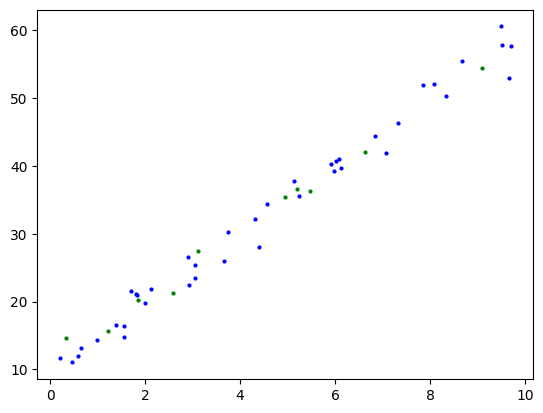

In [12]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.show()

In [13]:

# pythorch ann

In [14]:
from torch import nn

class SimpleLinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.weights = nn.Parameter(torch.randn(1,dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1,dtype=torch.float), requires_grad=True)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias     # x = data 



In [15]:
torch.manual_seed(42)

model_0 = SimpleLinearRegressionModel()
#model_0 = torch.compile(model_0)

In [16]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [17]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [18]:
with torch.inference_mode():
    y_pred = model_0(X_test)

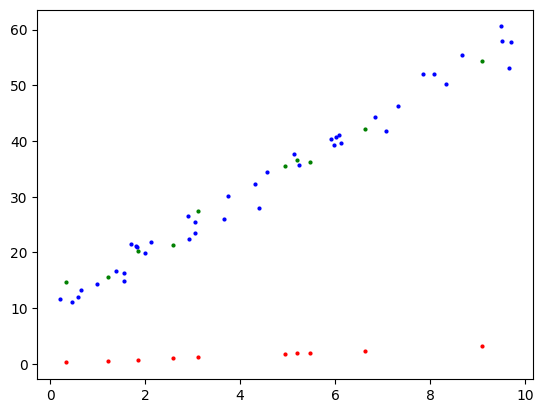

In [19]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_pred, c="r", s=4, label="Predictions")
plt.show()

In [20]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.SGD(params = model_0.parameters(), lr=0.01)

In [21]:
torch.manual_seed(42)

epochs = 120
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    #train  mode
    model_0.train()

    y_pred = model_0(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 5 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            

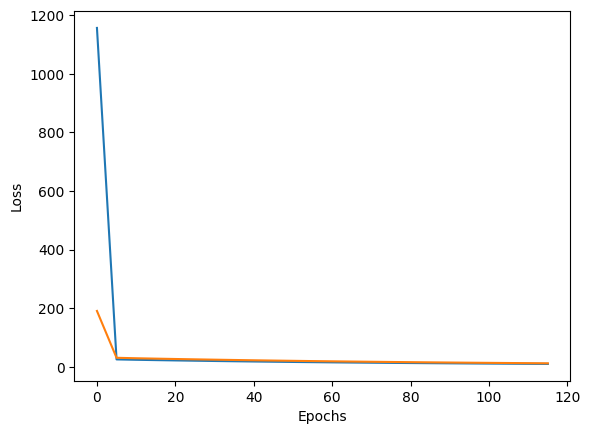

In [24]:
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.show()

In [25]:
model_0.state_dict()

OrderedDict([('weights', tensor([5.7069])), ('bias', tensor([5.4503]))])

In [26]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)


In [27]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [28]:
y_preds

tensor([12.4149, 33.7097,  7.4128, 57.3447, 20.2187, 43.2600, 23.2394, 35.1302,
        36.6507, 15.9998], dtype=torch.float64)

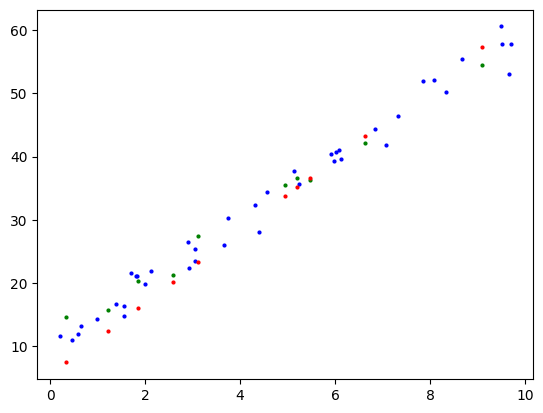

In [29]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")
plt.show()